<a href="https://colab.research.google.com/github/AngelHdz31/Proyecto_MachinceLearning_Mundial_2026/blob/main/Proyecto_MachineLearning_Mundial2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Predicción del Campeón del Mundial 2026
### Proyecto de Machine Learning

---

**Alumno:** [Angel Hernandez Ramirez]
**Materia:** Machine Learning
**Profesor(a):** [Lorena Diaz Gonzales ]
**Fecha:** Junio 2026

---

## Descripción

Este proyecto utiliza Machine Learning para predecir qué selección tiene
mayor probabilidad de ganar el Mundial 2026. A partir de un dataset histórico
de casi 50,000 partidos internacionales, se entrenan modelos que predicen el
resultado de cada partido, y luego se simula el torneo completo miles de veces
para estimar la probabilidad de campeón de cada selección.

**Técnicas utilizadas:** Regresión Logística, Random Forest y Máquinas de
Soporte Vectorial (SVM).

**Variables clave:** forma reciente, goles promedio (ataque/defensa) y un
sistema de rating Elo calculado a partir del historial de partidos.

## Contenido

1. Dataset y objetivos
2. Limpieza de datos
3. Análisis estadístico
4. Creación y selección de variables
5. Modelos: Regresión Logística, Random Forest, SVM
6. Comparación de resultados
7. Simulación del Mundial 2026
8. Conclusiones

## 1. Dataset

El dataset que voy a utilizar se llama **Resultados del fútbol internacional De 1872 a 2025**, obtenido de Kaggle. Contiene el registro histórico
de casi 50,000 partidos de selecciones nacionales desde 1872 hasta la
actualidad, lo que lo convierte en una de las bases de datos más completas
de fútbol internacional

Cada partido incluye 9 variables:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| date | Texto (fecha) | Fecha en que se jugó el partido |
| home_team | Texto | Equipo local |
| away_team | Texto | Equipo visitante |
| home_score | Decimal | Goles del equipo local |
| away_score | Decimal | Goles del equipo visitante |
| tournament | Texto | Tipo de torneo (Mundial, eliminatoria, Copa América, etc.) |
| city | Texto | Ciudad donde se jugó |
| country | Texto | País sede del partido |
| neutral | Verdadero/Falso | Si el partido se jugó en cancha neutral |



## 2. Objetivo y variable a predecir

**Objetivo:** predecir qué selección tiene mayor probabilidad de ganar
el Mundial 2026 usando Machine Learning.

Voy a entrenar un modelo de **regresión logística multinomial** que
prediga el resultado de cada partido entre dos selecciones.

La variable que voy a predecir (target) tiene tres posibles valores:

- **L** → gana el local
- **E** → empate
- **V** → gana el visitante

Con ese modelo funcionando, voy a simular el Mundial completo 10,000
veces y contar cuántas veces gana cada selección. Esa frecuencia será
la probabilidad de ser campeón.
Posteriormente implementar también un **Random Forest**, para comparar su desempeño contra la regresión logística y determinar cuál predice mejor los resultados.

In [5]:
import pandas as pd

df = pd.read_csv("results.csv")
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (49437, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [6]:
# Ver si hay valores faltantes en alguna columna
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


In [7]:
# Ver que partidos son los que tinen valores faltantes que son los de este mundial
print("Partidos sin marcador:")
print(df[df['home_score'].isnull()]['tournament'].value_counts())

Partidos sin marcador:
tournament
FIFA World Cup    72
Name: count, dtype: int64


---
# AVANCE #2: Preprocesamiento, Análisis Estadístico y Primera Técnica

In [8]:
# LIMPIEZA DE DATOS
# Separamos partidos futuros, convertimos fechas y creamos el target.

# 1) Separar los 72 partidos del Mundial 2026 que aún no se juegan
df_futuros = df[df['home_score'].isnull()].copy()
df = df[df['home_score'].notna()].copy()

# 2) Convertir la fecha a formato fecha real
df['date'] = pd.to_datetime(df['date'])

# 3) Crear la variable objetivo (target): resultado del partido
#    L = gana local, V = gana visitante, E = empate
def resultado(row):
    if row['home_score'] > row['away_score']:
        return 'L'
    elif row['home_score'] < row['away_score']:
        return 'V'
    else:
        return 'E'

df['result'] = df.apply(resultado, axis=1)

print("Partidos para entrenar:", len(df))
print("Partidos futuros (Mundial 2026):", len(df_futuros))
df[['date','home_team','away_team','home_score','away_score','result']].head()

Partidos para entrenar: 49365
Partidos futuros (Mundial 2026): 72


,date,home_team,away_team,home_score,away_score,result
0,1872-11-30,Scotland,England,0.0,0.0,E
1,1873-03-08,England,Scotland,4.0,2.0,L
2,1874-03-07,Scotland,England,2.0,1.0,L
3,1875-03-06,England,Scotland,2.0,2.0,E
4,1876-03-04,Scotland,England,3.0,0.0,L


In [9]:
# FILTRAR SOLO TORNEOS COMPETITIVOS
# Quitamos amistosos y torneos menores que no reflejan el nivel real.
torneos_importantes = [
    'FIFA World Cup', 'FIFA World Cup qualification',
    'UEFA Euro', 'UEFA Euro qualification',
    'Copa América', 'African Cup of Nations',
    'African Cup of Nations qualification',
    'AFC Asian Cup', 'AFC Asian Cup qualification',
    'CONCACAF Nations League', 'UEFA Nations League', 'Gold Cup'
]

df_comp = df[df['tournament'].isin(torneos_importantes)].copy()
df_comp = df_comp.sort_values('date').reset_index(drop=True)

print("Partidos antes del filtro:", len(df))
print("Partidos competitivos:", len(df_comp))

Partidos antes del filtro: 49365
Partidos competitivos: 19738


## Análisis estadístico

Distribución de resultados:
result
L    9910
V    5544
E    4284
Name: count, dtype: int64

En porcentaje:
result
L    50.2
V    28.1
E    21.7
Name: proportion, dtype: float64

Promedio de goles local: 1.71
Promedio de goles visitante: 1.09


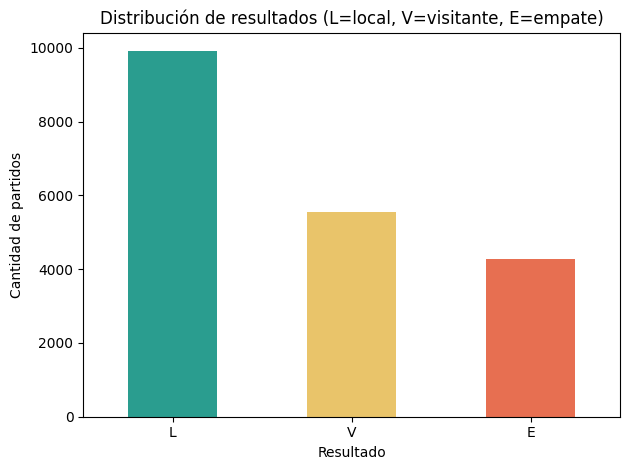

In [10]:
# ANÁLISIS ESTADÍSTICO EXPLORATORIO
# Exploramos cómo se distribuyen los datos antes de modelar.
import matplotlib.pyplot as plt

# Distribución de resultados
print("Distribución de resultados:")
print(df_comp['result'].value_counts())
print("\nEn porcentaje:")
print((df_comp['result'].value_counts(normalize=True)*100).round(1))

print("\nPromedio de goles local:", round(df_comp['home_score'].mean(),2))
print("Promedio de goles visitante:", round(df_comp['away_score'].mean(),2))

# Gráfica
df_comp['result'].value_counts().plot(kind='bar', color=['#2a9d8f','#e9c46a','#e76f51'])
plt.title('Distribución de resultados (L=local, V=visitante, E=empate)')
plt.ylabel('Cantidad de partidos'); plt.xlabel('Resultado')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Selección de variables (features)

In [11]:
# CREAR VARIABLE: forma reciente
from tqdm import tqdm

def forma_reciente(equipo, fecha, df, n=5):
    mask = (((df['home_team']==equipo)|(df['away_team']==equipo)) & (df['date']<fecha))
    partidos = df[mask].tail(n)
    pts = 0
    for _, r in partidos.iterrows():
        if r['home_team']==equipo:
            # Si el equipo jugó de local: gana si result == 'L'
            pts += 3 if r['result']=='L' else (1 if r['result']=='E' else 0)
        else:
            # Si jugó de visitante: gana si result == 'V'
            pts += 3 if r['result']=='V' else (1 if r['result']=='E' else 0)
    return pts

df_comp['forma_home'] = [forma_reciente(r['home_team'], r['date'], df_comp)
                         for _, r in tqdm(df_comp.iterrows(), total=len(df_comp))]
df_comp['forma_away'] = [forma_reciente(r['away_team'], r['date'], df_comp)
                         for _, r in tqdm(df_comp.iterrows(), total=len(df_comp))]
df_comp['forma_diff'] = df_comp['forma_home'] - df_comp['forma_away']
df_comp['es_neutral'] = df_comp['neutral'].astype(int)

print("\n¡Corregido! Verificación:")
print(df_comp[['forma_home','forma_away','forma_diff','es_neutral']].describe())

100%|██████████| 19738/19738 [01:14<00:00, 265.34it/s]


¡Corregido! Verificación:
         forma_home    forma_away    forma_diff    es_neutral
count  19738.000000  19738.000000  19738.000000  19738.000000
mean       6.871010      6.841271      0.029740      0.223630
std        3.776443      3.740978      4.959212      0.416687
min        0.000000      0.000000    -15.000000      0.000000
25%        4.000000      4.000000     -3.000000      0.000000
50%        7.000000      7.000000      0.000000      0.000000
75%       10.000000     10.000000      3.000000      0.000000
max       15.000000     15.000000     15.000000      1.000000


In [12]:
# PREPARAR DATOS PARA EL MODELO
# Separamos X (variables) e y (target) y dividimos por orden cronológico.

from sklearn.preprocessing import LabelEncoder

features = ['forma_home', 'forma_away', 'forma_diff', 'es_neutral']
X = df_comp[features]
y = df_comp['result']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Codificación del target:", dict(zip(le.classes_, range(len(le.classes_)))))

split = int(len(X)*0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y_encoded[:split], y_encoded[split:]

print("Entrenamiento:", len(X_train), "| Prueba:", len(X_test))

Codificación del target: {'E': 0, 'L': 1, 'V': 2}
Entrenamiento: 15790 | Prueba: 3948


## Primera técnica: Regresión Logística

In [13]:
# PRIMER ENTRENAMIENTO — REGRESIÓN LOGÍSTICA (4 variables base)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Definir explícitamente las 4 variables base de este modelo
features_v1 = ['forma_home', 'forma_away', 'forma_diff', 'es_neutral']
X1 = df_comp[features_v1]

# Misma división temporal (y_train, y_test ya existen)
split = int(len(X1)*0.8)
X1_train, X1_test = X1.iloc[:split], X1.iloc[split:]

# Entrenar el modelo
modelo_v1 = LogisticRegression(max_iter=1000)
modelo_v1.fit(X1_train, y_train)

# Predicciones en entrenamiento y prueba
pred_train = modelo_v1.predict(X1_train)
pred_test  = modelo_v1.predict(X1_test)

# Exactitud y log-loss en cada conjunto
acc_train  = accuracy_score(y_train, pred_train)
acc_test   = accuracy_score(y_test,  pred_test)
loss_train = log_loss(y_train, modelo_v1.predict_proba(X1_train))
loss_test  = log_loss(y_test,  modelo_v1.predict_proba(X1_test))

print("=== MODELO 1: REGRESIÓN LOGÍSTICA (4 variables) ===")
print(f"{'Métrica':<15}{'Entrenamiento':<18}{'Prueba':<10}")
print("-"*45)
print(f"{'Exactitud':<15}{acc_train*100:>6.1f}%{'':<11}{acc_test*100:>6.1f}%")
print(f"{'Log-loss':<15}{loss_train:>6.3f}{'':<12}{loss_test:>6.3f}")

# Detección de sobreajuste
diferencia = (acc_train - acc_test) * 100
print("\nInterpretación:")
if diferencia > 10:
    print(f"⚠ El modelo va {diferencia:.1f} puntos mejor en entrenamiento (posible sobreajuste).")
else:
    print(f"✓ Diferencia pequeña ({diferencia:.1f} puntos): el modelo generaliza bien.")

=== MODELO 1: REGRESIÓN LOGÍSTICA (4 variables) ===
Métrica        Entrenamiento     Prueba    
---------------------------------------------
Exactitud        56.4%             53.4%
Log-loss        0.944             0.978

Interpretación:
✓ Diferencia pequeña (3.0 puntos): el modelo generaliza bien.


## Mejora del modelo: creación de nuevas variables

En el primer entrenamiento, la regresión logística obtuvo una exactitud baja
(~46%), apenas por encima del azar. Esto se debe a que solo se usaron 4 variables
basadas en la forma reciente, que es algo limitado.

Para mejorar el modelo:

1. **Crear nuevas variables** que aporten más información sobre cada equipo:
   los goles promedio que marca (ataque) y los goles promedio que recibe
   (defensa) en sus últimos partidos.

2. **Analizar las variables con una matriz de correlación**

3. **Re-entrenar la regresión logística** con el nuevo conjunto de variables
   y comparar la exactitud contra el modelo anterior, para comprobar si la
   mejora funcionó.


In [14]:
# CREAR MÁS VARIABLES: goles promedio a favor y en contra

from tqdm import tqdm

def goles_promedio(equipo, fecha, df, n=5, marcados=True):
    mask = (((df['home_team']==equipo)|(df['away_team']==equipo)) & (df['date']<fecha))
    partidos = df[mask].tail(n)
    if len(partidos)==0: return 0
    goles = []
    for _, r in partidos.iterrows():
        if r['home_team']==equipo:
            goles.append(r['home_score'] if marcados else r['away_score'])
        else:
            goles.append(r['away_score'] if marcados else r['home_score'])
    return round(sum(goles)/len(goles), 2)

print("Calculando goles promedio... (tarda unos minutos)")
df_comp['ataque_home']  = [goles_promedio(r['home_team'], r['date'], df_comp, marcados=True)
                           for _, r in tqdm(df_comp.iterrows(), total=len(df_comp))]
df_comp['ataque_away']  = [goles_promedio(r['away_team'], r['date'], df_comp, marcados=True)
                           for _, r in tqdm(df_comp.iterrows(), total=len(df_comp))]
df_comp['defensa_home'] = [goles_promedio(r['home_team'], r['date'], df_comp, marcados=False)
                           for _, r in tqdm(df_comp.iterrows(), total=len(df_comp))]
df_comp['defensa_away'] = [goles_promedio(r['away_team'], r['date'], df_comp, marcados=False)
                           for _, r in tqdm(df_comp.iterrows(), total=len(df_comp))]

print("¡Listo! Ahora tienes 8 variables numéricas.")

Calculando goles promedio... (tarda unos minutos)


100%|██████████| 19738/19738 [01:25<00:00, 232.00it/s]

¡Listo! Ahora tienes 8 variables numéricas.


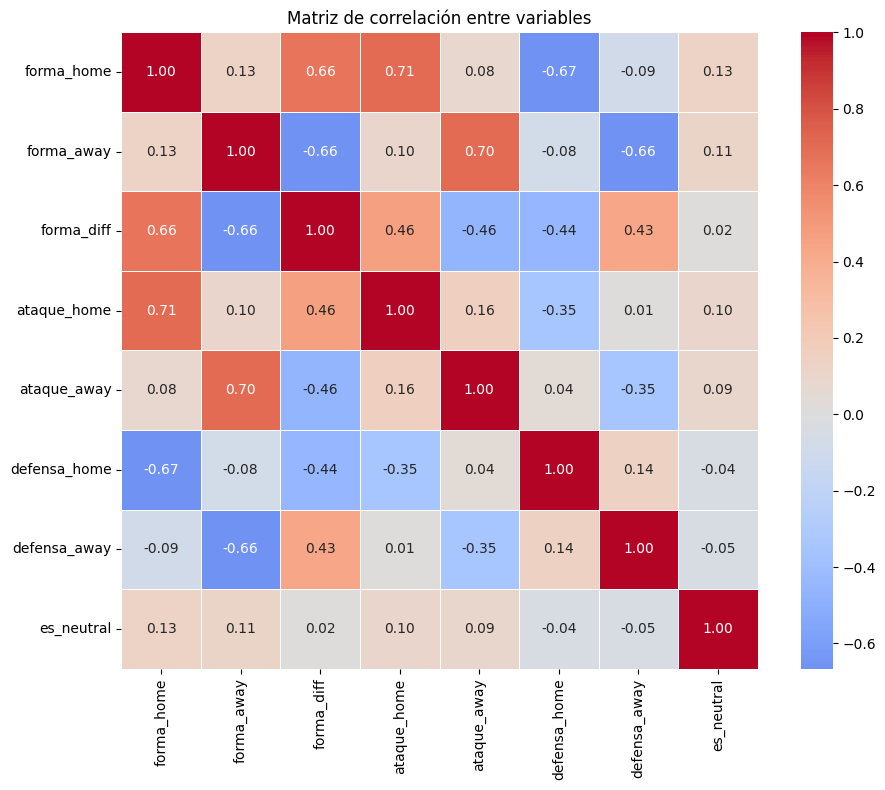

=== TOP 5 PARES MÁS CORRELACIONADOS ===
 1. forma_home ↔ ataque_home: +0.71
 2. forma_away ↔ ataque_away: +0.70
 3. forma_home ↔ defensa_home: -0.67
 4. forma_home ↔ forma_diff: +0.66
 5. forma_away ↔ defensa_away: -0.66


In [15]:

# MATRIZ DE CORRELACIÓN S
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

variables_numericas = ['forma_home', 'forma_away', 'forma_diff',
                       'ataque_home', 'ataque_away',
                       'defensa_home', 'defensa_away', 'es_neutral']

matriz_corr = df_comp[variables_numericas].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de correlación entre variables')
plt.tight_layout()
plt.show()

# --- TOP 10 correlaciones más altas
corr_abs = matriz_corr.abs()
mascara = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
pares = corr_abs.where(mascara).stack().sort_values(ascending=False)

print("=== TOP 5 PARES MÁS CORRELACIONADOS ===")
for i, ((v1, v2), valor) in enumerate(pares.head(5).items(), 1):
    # mostramos el valor real (con signo), no el absoluto
    real = matriz_corr.loc[v1, v2]
    print(f"{i:2}. {v1} ↔ {v2}: {real:+.2f}")

In [16]:
# SELECCIÓN DE VARIABLES: eliminar redundantes según la matriz
# La matriz mostró que 'forma_diff' está muy correlacionada con
# 'forma_home' y 'forma_away' (porque se calcula de ellas).
# La quitamos para evitar información repetida.

# Variables finales que usaremos
features = ['forma_home', 'forma_away',
            'ataque_home', 'ataque_away',
            'defensa_home', 'defensa_away', 'es_neutral']

print("Variables eliminadas por redundancia: forma_diff")
print(f"Variables finales seleccionadas ({len(features)}):")
for f in features:
    print("  -", f)

Variables eliminadas por redundancia: forma_diff
Variables finales seleccionadas (7):
  - forma_home
  - forma_away
  - ataque_home
  - ataque_away
  - defensa_home
  - defensa_away
  - es_neutral


In [17]:
# SEGUNDO ENTRENAMIENTO — Regresión Logística (7 variables)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ---------- MODELO 1: base con 4 variables (para comparar) ----------
features_v1 = ['forma_home', 'forma_away', 'forma_diff', 'es_neutral']
X1 = df_comp[features_v1]
split = int(len(X1)*0.8)
X1_train, X1_test = X1.iloc[:split], X1.iloc[split:]

scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X1_train)
X1_test_sc  = scaler1.transform(X1_test)

modelo_v1 = LogisticRegression(max_iter=1000)
modelo_v1.fit(X1_train_sc, y_train)
acc_v1 = accuracy_score(y_test, modelo_v1.predict(X1_test_sc))

# ---------- MODELO 2: final con 7 variables (sin forma_diff) ----------
features_v2 = ['forma_home', 'forma_away',
               'ataque_home', 'ataque_away',
               'defensa_home', 'defensa_away', 'es_neutral']
X2 = df_comp[features_v2]
X2_train, X2_test = X2.iloc[:split], X2.iloc[split:]

scaler = StandardScaler()
X2_train_sc = scaler.fit_transform(X2_train)
X2_test_sc  = scaler.transform(X2_test)

modelo_v2 = LogisticRegression(max_iter=1000)
modelo_v2.fit(X2_train_sc, y_train)

# --- Predicciones sobre AMBOS conjuntos ---
pred_train = modelo_v2.predict(X2_train_sc)
pred_v2    = modelo_v2.predict(X2_test_sc)   # la usa la matriz de confusión

# --- Exactitud en entrenamiento y prueba ---
acc_train  = accuracy_score(y_train, pred_train)
acc_v2     = accuracy_score(y_test,  pred_v2)

# --- Tabla: entrenamiento vs prueba ---
print("="*50)
print("   MODELO 2: Regresión Logística con 7 variables")
print("="*50)
print(f"{'Métrica':<15}{'Entrenamiento':<18}{'Prueba':<10}")
print("-"*50)
print(f"{'Exactitud':<15}{acc_train*100:>6.1f}%{'':<11}{acc_v2*100:>6.1f}%")

# --- Detección de sobreajuste ---
diferencia = (acc_train - acc_v2) * 100
print("\nInterpretación:")
if diferencia > 10:
    print(f"⚠ El modelo va {diferencia:.1f} puntos mejor en entrenamiento.")
    print("  Posible sobreajuste: está memorizando en vez de generalizar.")
else:
    print(f"✓ Diferencia pequeña ({diferencia:.1f} puntos): el modelo generaliza bien,")
    print("  no hay sobreajuste preocupante.")

# --- Comparación entre los dos modelos ---
print("\n" + "="*50)
print("   COMPARACIÓN ENTRE MODELOS (en prueba)")
print("="*50)
print(f"Modelo 1 (4 variables): {acc_v1*100:.1f}%")
print(f"Modelo 2 (7 variables): {acc_v2*100:.1f}%")
print(f"Mejora: +{(acc_v2-acc_v1)*100:.1f} puntos")

   MODELO 2: Regresión Logística con 7 variables
Métrica        Entrenamiento     Prueba    
--------------------------------------------------
Exactitud        57.7%             55.7%

Interpretación:
✓ Diferencia pequeña (2.0 puntos): el modelo generaliza bien,
  no hay sobreajuste preocupante.

   COMPARACIÓN ENTRE MODELOS (en prueba)
Modelo 1 (4 variables): 53.4%
Modelo 2 (7 variables): 55.7%
Mejora: +2.4 puntos


In [18]:
# CALCULAR EL RATING ELO DE CADA SELECCIÓN
# El Elo mide la fuerza de cada equipo según su historial.

from tqdm import tqdm

# Usamos el dataset histórico completo (con fechas ya convertidas)
df_elo = df[df['home_score'].notna()].copy()
df_elo['date'] = pd.to_datetime(df_elo['date'])
df_elo = df_elo.sort_values('date').reset_index(drop=True)

# Todos empiezan en 1500
elo = {}
K = 30  # qué tan rápido cambia el Elo

def get_elo(equipo):
    return elo.get(equipo, 1500)

# Guardaremos el Elo que tenía cada equipo ANTES de cada partido
elo_home_antes = []
elo_away_antes = []

print("Calculando Elo recorriendo todos los partidos históricos...")
for _, row in tqdm(df_elo.iterrows(), total=len(df_elo)):
    local, visitante = row['home_team'], row['away_team']
    el, ev = get_elo(local), get_elo(visitante)

    # Guardar el Elo antes del partido
    elo_home_antes.append(el)
    elo_away_antes.append(ev)

    # Resultado esperado según la diferencia de Elo (fórmula estándar)
    esperado_local = 1 / (1 + 10 ** ((ev - el) / 400))

    # Resultado real del partido
    if row['home_score'] > row['away_score']:
        real_local = 1.0
    elif row['home_score'] < row['away_score']:
        real_local = 0.0
    else:
        real_local = 0.5

    # Actualizar el Elo: el cambio depende de qué tan esperado era el resultado
    cambio = K * (real_local - esperado_local)
    elo[local] = el + cambio
    elo[visitante] = ev - cambio

df_elo['elo_home_antes'] = elo_home_antes
df_elo['elo_away_antes'] = elo_away_antes

print("\n¡Elo calculado! Top 15 selecciones por Elo actual:")
ranking = sorted(elo.items(), key=lambda x: x[1], reverse=True)[:15]
for i, (equipo, puntos) in enumerate(ranking, 1):
    print(f"  {i:2}. {equipo}: {puntos:.0f}")

Calculando Elo recorriendo todos los partidos históricos...


100%|██████████| 49365/49365 [00:02<00:00, 19956.08it/s]


¡Elo calculado! Top 15 selecciones por Elo actual:
   1. Argentina: 2045
   2. Spain: 2042
   3. France: 1985
   4. Brazil: 1948
   5. Portugal: 1946
   6. Germany: 1943
   7. England: 1939
   8. Colombia: 1924
   9. Japan: 1911
  10. Morocco: 1909
  11. Netherlands: 1909
  12. Ecuador: 1886
  13. Italy: 1884
  14. Belgium: 1883
  15. Croatia: 1877


In [19]:
# RE-ENTRENAR LA REGRESIÓN LOGÍSTICA CON EL ELO
# Agregamos el Elo como variable y comparamos contra el modelo
# anterior para ver cuánto mejora.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss

# --- Cruzar el Elo con los partidos competitivos ---
df_elo['llave']  = df_elo['date'].astype(str) + df_elo['home_team'] + df_elo['away_team']
df_comp['llave'] = df_comp['date'].astype(str) + df_comp['home_team'] + df_comp['away_team']

mapa_home = dict(zip(df_elo['llave'], df_elo['elo_home_antes']))
mapa_away = dict(zip(df_elo['llave'], df_elo['elo_away_antes']))
df_comp['elo_home'] = df_comp['llave'].map(mapa_home)
df_comp['elo_away'] = df_comp['llave'].map(mapa_away)
df_comp['elo_diff'] = df_comp['elo_home'] - df_comp['elo_away']

print("Partidos sin Elo asignado:", df_comp['elo_diff'].isnull().sum())

# --- Variables CON Elo ---
features_elo = ['forma_home', 'forma_away',
                'ataque_home', 'ataque_away',
                'defensa_home', 'defensa_away', 'es_neutral',
                'elo_home', 'elo_away', 'elo_diff']

X3 = df_comp[features_elo]
split = int(len(X3)*0.8)
X3_train, X3_test = X3.iloc[:split], X3.iloc[split:]

# Escalar (el Elo tiene números grandes ~2000)
scaler3 = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc  = scaler3.transform(X3_test)

# Entrenar
modelo_elo = LogisticRegression(max_iter=1000)
modelo_elo.fit(X3_train_sc, y_train)

# Métricas en entrenamiento y prueba
acc_train = accuracy_score(y_train, modelo_elo.predict(X3_train_sc))
acc_elo   = accuracy_score(y_test,  modelo_elo.predict(X3_test_sc))

print("\n=== REGRESIÓN LOGÍSTICA CON ELO ===")
print(f"Exactitud entrenamiento: {acc_train*100:.1f}%")
print(f"Exactitud prueba:        {acc_elo*100:.1f}%")

# Comparar contra el modelo sin Elo
print("\n=== COMPARACIÓN ===")
print(f"Sin Elo (7 variables):  {acc_v2*100:.1f}%")
print(f"Con Elo (10 variables): {acc_elo*100:.1f}%")
print(f"Mejora: +{(acc_elo-acc_v2)*100:.1f} puntos")

Partidos sin Elo asignado: 0

=== REGRESIÓN LOGÍSTICA CON ELO ===
Exactitud entrenamiento: 62.4%
Exactitud prueba:        61.6%

=== COMPARACIÓN ===
Sin Elo (7 variables):  55.7%
Con Elo (10 variables): 61.6%
Mejora: +5.8 puntos


In [20]:
# RANDOM FOREST — versión simple (sin optimizar)
# Usa las mismas variables CON Elo que la regresión logística.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Entrenar con valores básicos (sin afinar todavía)
rf_simple = RandomForestClassifier(
    n_estimators=100,      # número de árboles
    random_state=42        # para que el resultado sea reproducible
)
rf_simple.fit(X3_train_sc, y_train)

# Evaluar en entrenamiento y prueba
acc_train_rf = accuracy_score(y_train, rf_simple.predict(X3_train_sc))
acc_rf       = accuracy_score(y_test,  rf_simple.predict(X3_test_sc))

print("=== RANDOM FOREST (simple) ===")
print(f"Exactitud entrenamiento: {acc_train_rf*100:.1f}%")
print(f"Exactitud prueba:        {acc_rf*100:.1f}%")

# Comparar con la regresión logística
print("\n=== COMPARACIÓN ===")
print(f"Regresión Logística (prueba): {acc_elo*100:.1f}%")
print(f"Random Forest (prueba):       {acc_rf*100:.1f}%")

=== RANDOM FOREST (simple) ===
Exactitud entrenamiento: 100.0%
Exactitud prueba:        59.7%

=== COMPARACIÓN ===
Regresión Logística (prueba): 61.6%
Random Forest (prueba):       59.7%


In [21]:
# RANDOM FOREST con GridSearch — corrige el sobreajuste

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Valores a probar para controlar la complejidad
parametros_rf = {
    'n_estimators': [100, 200],          # número de árboles
    'max_depth': [5, 10, 15],            # profundidad máxima (clave contra sobreajuste)
    'min_samples_leaf': [5, 10, 20]      # mínimo de muestras por hoja
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parametros_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X3_train_sc, y_train)

print("\n=== MEJORES HIPERPARÁMETROS ===")
print("Mejor combinación:", grid_rf.best_params_)

# Evaluar el mejor modelo
mejor_rf = grid_rf.best_estimator_
acc_train_opt = accuracy_score(y_train, mejor_rf.predict(X3_train_sc))
acc_rf_opt    = accuracy_score(y_test,  mejor_rf.predict(X3_test_sc))

print("\n=== RANDOM FOREST OPTIMIZADO ===")
print(f"Exactitud entrenamiento: {acc_train_opt*100:.1f}%")
print(f"Exactitud prueba:        {acc_rf_opt*100:.1f}%")

print("\n=== ANTES vs DESPUÉS del GridSearch ===")
print(f"RF simple    - Entrenamiento: 100.0% | Prueba: {acc_rf*100:.1f}%")
print(f"RF optimizado- Entrenamiento: {acc_train_opt*100:.1f}% | Prueba: {acc_rf_opt*100:.1f}%")


=== MEJORES HIPERPARÁMETROS ===
Mejor combinación: {'max_depth': 10, 'min_samples_leaf': 20, 'n_estimators': 200}

=== RANDOM FOREST OPTIMIZADO ===
Exactitud entrenamiento: 64.4%
Exactitud prueba:        61.6%

=== ANTES vs DESPUÉS del GridSearch ===
RF simple    - Entrenamiento: 100.0% | Prueba: 59.7%
RF optimizado- Entrenamiento: 64.4% | Prueba: 61.6%


In [22]:
# MÁQUINA DE SOPORTE VECTORIAL (SVM)
# Tercera técnica: busca la mejor frontera que separa los
# resultados (local, empate, visitante). Usa las mismas
# variables CON Elo y datos escalados.
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("Entrenando la SVM... (puede tardar unos minutos)")

# Crear y entrenar la SVM
# probability=True permite que dé probabilidades, no solo la clase
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X3_train_sc, y_train)

# Evaluar en entrenamiento y prueba
acc_train_svm = accuracy_score(y_train, svm.predict(X3_train_sc))
acc_svm       = accuracy_score(y_test,  svm.predict(X3_test_sc))

print("\n=== MÁQUINA DE SOPORTE VECTORIAL (SVM) ===")
print(f"Exactitud entrenamiento: {acc_train_svm*100:.1f}%")
print(f"Exactitud prueba:        {acc_svm*100:.1f}%")

# Detección de sobreajuste
brecha = (acc_train_svm - acc_svm) * 100
print(f"\nBrecha entrenamiento-prueba: {brecha:.1f} puntos")
if brecha > 10:
    print("⚠ Posible sobreajuste.")
else:
    print("✓ Generaliza bien.")

# Comparación con los otros modelos
print("\n=== COMPARACIÓN DE LAS 3 TÉCNICAS (prueba) ===")
print(f"Regresión Logística: {acc_elo*100:.1f}%")
print(f"Random Forest:       {acc_rf_opt*100:.1f}%")
print(f"SVM:                 {acc_svm*100:.1f}%")

Entrenando la SVM... (puede tardar unos minutos)

=== MÁQUINA DE SOPORTE VECTORIAL (SVM) ===
Exactitud entrenamiento: 63.0%
Exactitud prueba:        61.2%

Brecha entrenamiento-prueba: 1.8 puntos
✓ Generaliza bien.

=== COMPARACIÓN DE LAS 3 TÉCNICAS (prueba) ===
Regresión Logística: 61.6%
Random Forest:       61.6%
SVM:                 61.2%


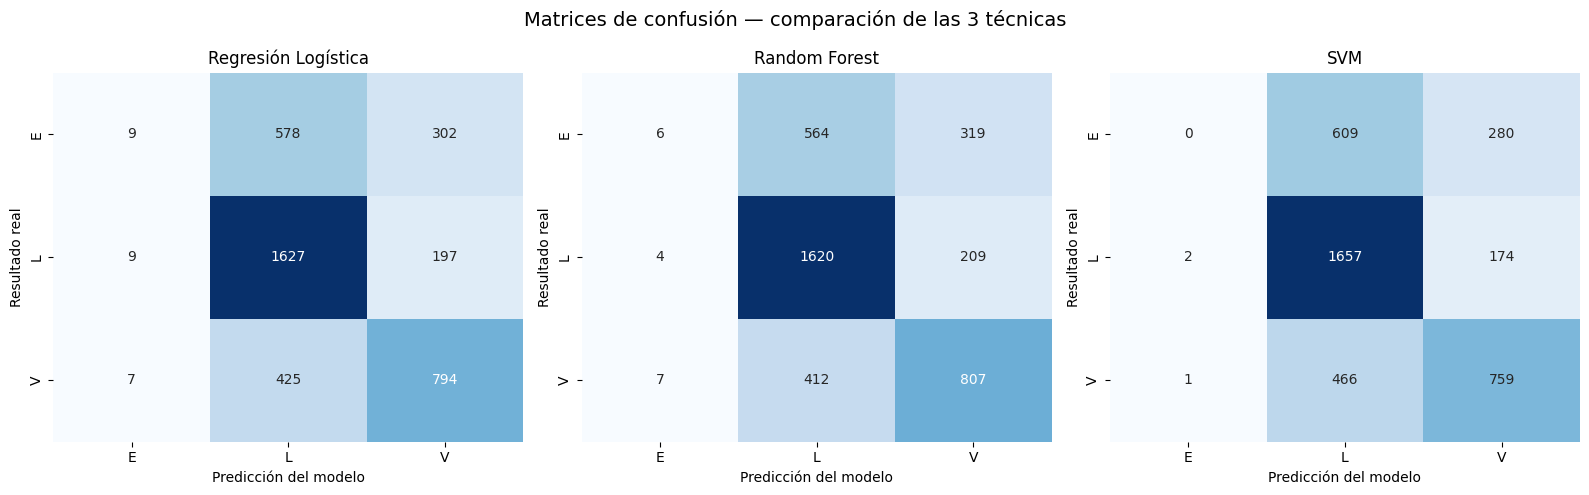

=== ACIERTOS POR TIPO DE RESULTADO ===

Regresión Logística — acertó 2430 de 3948 (61.6%):
   E: 9/889 partidos (1%)
   L: 1627/1833 partidos (89%)
   V: 794/1226 partidos (65%)

Random Forest — acertó 2433 de 3948 (61.6%):
   E: 6/889 partidos (1%)
   L: 1620/1833 partidos (88%)
   V: 807/1226 partidos (66%)

SVM — acertó 2416 de 3948 (61.2%):
   E: 0/889 partidos (0%)
   L: 1657/1833 partidos (90%)
   V: 759/1226 partidos (62%)



In [28]:
# MATRICES DE CONFUSIÓN DE LAS 3 TÉCNICAS
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones de cada modelo en el conjunto de prueba
pred_lr  = modelo_elo.predict(X3_test_sc)   # Regresión Logística con Elo
pred_rf  = mejor_rf.predict(X3_test_sc)     # Random Forest optimizado
pred_svm = svm.predict(X3_test_sc)          # SVM

modelos = [
    ('Regresión Logística', pred_lr),
    ('Random Forest', pred_rf),
    ('SVM', pred_svm)
]

# Tres matrices lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, pred) in zip(axes, modelos):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
    ax.set_title(nombre)
    ax.set_xlabel('Predicción del modelo')
    ax.set_ylabel('Resultado real')

plt.suptitle('Matrices de confusión — comparación de las 3 técnicas', fontsize=14)
plt.tight_layout()
plt.show()

# Interpretación automática: aciertos por tipo de resultado en cada modelo
print("=== ACIERTOS POR TIPO DE RESULTADO ===\n")
clases = list(le.classes_)
for nombre, pred in modelos:
    cm = confusion_matrix(y_test, pred)
    total = cm.sum()
    aciertos = sum(cm[i][i] for i in range(len(clases)))
    print(f"{nombre} — acertó {aciertos} de {total} ({aciertos/total*100:.1f}%):")
    for i, clase in enumerate(clases):
        reales = cm[i].sum()
        bien = cm[i][i]
        pct = (bien/reales*100) if reales > 0 else 0
        print(f"   {clase}: {bien}/{reales} partidos ({pct:.0f}%)")
    print()

In [23]:
# PASO 1: Calcular las features de cada selección del Mundial
# Para cada equipo calculamos su forma, ataque, defensa y Elo
import pandas as pd

# Fecha de referencia (inicio del Mundial 2026)
fecha_mundial = pd.to_datetime('2026-06-11')

# Asegurar que las fechas de df_comp sean tipo fecha
df_comp['date'] = pd.to_datetime(df_comp['date'])

# Todos los equipos que existen en el historial
todos_equipos = set(df_comp['home_team']) | set(df_comp['away_team'])

# Calcular y guardar las stats de cada equipo
stats_equipo = {}
for equipo in todos_equipos:
    stats_equipo[equipo] = {
        'forma':   forma_reciente(equipo, fecha_mundial, df_comp),
        'ataque':  goles_promedio(equipo, fecha_mundial, df_comp, marcados=True),
        'defensa': goles_promedio(equipo, fecha_mundial, df_comp, marcados=False),
        'elo':     get_elo(equipo)
    }

print("Features calculadas para", len(stats_equipo), "equipos.")
print("\nEjemplo - Argentina:")
print(stats_equipo['Argentina'])
print("\nEjemplo - Spain:")
print(stats_equipo['Spain'])

Features calculadas para 223 equipos.

Ejemplo - Argentina:
{'forma': 10, 'ataque': 1.8, 'defensa': 0.6, 'elo': 2044.9478405124048}

Ejemplo - Spain:
{'forma': 13, 'ataque': 3.6, 'defensa': 0.4, 'elo': 2041.719124136664}


In [24]:
# PASO 2: Función que predice un partido entre dos selecciones
# Arma las features del partido y usa el modelo (con Elo) para
# devolver las probabilidades de [empate, local, visitante].

import numpy as np
import pandas as pd

def predecir_partido(local, visitante, neutral=1):
    sl = stats_equipo[local]
    sv = stats_equipo[visitante]
    # Construir la fila con las mismas 10 variables del modelo
    x = pd.DataFrame([{
        'forma_home': sl['forma'],   'forma_away': sv['forma'],
        'ataque_home': sl['ataque'], 'ataque_away': sv['ataque'],
        'defensa_home': sl['defensa'],'defensa_away': sv['defensa'],
        'es_neutral': neutral,
        'elo_home': sl['elo'], 'elo_away': sv['elo'],
        'elo_diff': sl['elo'] - sv['elo']
    }])[features_elo]
    # Escalar igual que en el entrenamiento y predecir
    x_sc = scaler3.transform(x)
    return modelo_elo.predict_proba(x_sc)[0]   # [prob_E, prob_L, prob_V]

# Probar la función con un par de partidos
print("Recordatorio de codificación:", dict(zip(le.classes_, range(len(le.classes_)))))
print()

for local, visit in [('Spain', 'Cape Verde'), ('Argentina', 'Jordan'), ('Brazil', 'Morocco')]:
    p = predecir_partido(local, visit)
    # El orden de p depende de le.classes_ (normalmente E=0, L=1, V=2)
    print(f"{local} vs {visit}:")
    print(f"   Local: {p[1]*100:.0f}% | Empate: {p[0]*100:.0f}% | Visitante: {p[2]*100:.0f}%")

Recordatorio de codificación: {'E': 0, 'L': 1, 'V': 2}

Spain vs Cape Verde:
   Local: 89% | Empate: 10% | Visitante: 1%
Argentina vs Jordan:
   Local: 82% | Empate: 15% | Visitante: 4%
Brazil vs Morocco:
   Local: 37% | Empate: 34% | Visitante: 30%


In [25]:
# ============================================================
# PASO 3: Los 12 grupos y la simulación de la fase de grupos
# ============================================================
import numpy as np

# Los 12 grupos del Mundial 2026 (nombres como en el dataset)
grupos = {
    'A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

# Verificar que todos los equipos existen en stats_equipo
faltantes = [e for eqs in grupos.values() for e in eqs if e not in stats_equipo]
print("Equipos faltantes:", faltantes if faltantes else "ninguno ✓")

def simular_partido(local, visitante, neutral=1):
    """Simula un partido y devuelve 'L', 'E' o 'V' según las probabilidades."""
    p = predecir_partido(local, visitante, neutral)  # [E, L, V]
    return np.random.choice(['E', 'L', 'V'], p=[p[0], p[1], p[2]])

def simular_grupo(equipos):
    """Simula todos contra todos y devuelve la tabla ordenada por puntos."""
    puntos = {e: 0 for e in equipos}
    for i in range(len(equipos)):
        for j in range(i+1, len(equipos)):
            local, visitante = equipos[i], equipos[j]
            res = simular_partido(local, visitante)
            if res == 'L': puntos[local] += 3
            elif res == 'V': puntos[visitante] += 3
            else: puntos[local] += 1; puntos[visitante] += 1
    tabla = sorted(equipos, key=lambda e: puntos[e] + np.random.random()*0.1, reverse=True)
    return tabla, puntos

# Probar simulando el Grupo A una vez
tabla_A, puntos_A = simular_grupo(grupos['A'])
print("\nSimulación del Grupo A:")
for pos, eq in enumerate(tabla_A, 1):
    print(f"  {pos}. {eq} ({puntos_A[eq]} pts)")

Equipos faltantes: ninguno ✓

Simulación del Grupo A:
  1. Mexico (6 pts)
  2. Czech Republic (6 pts)
  3. South Korea (4 pts)
  4. South Africa (1 pts)


In [26]:
def simular_eliminatoria(local, visitante):
    """En eliminatoria no hay empate: si empatan, desempata el de mejor Elo."""
    p = predecir_partido(local, visitante)  # [E, L, V]
    # Repartir la probabilidad del empate según quién es más fuerte
    p_local = p[1] + p[0] * (stats_equipo[local]['elo'] /
                             (stats_equipo[local]['elo'] + stats_equipo[visitante]['elo']))
    return local if np.random.random() < p_local else visitante

def simular_mundial():
    """Simula un Mundial completo y devuelve el campeón."""
    primeros, segundos, terceros = [], [], []
    for g, equipos in grupos.items():
        tabla, puntos = simular_grupo(equipos)
        primeros.append(tabla[0])
        segundos.append(tabla[1])
        terceros.append((tabla[2], puntos[tabla[2]]))

    # 8 mejores terceros (por puntos)
    mejores_terceros = [t[0] for t in sorted(terceros, key=lambda x: x[1] + np.random.random()*0.1,
                                             reverse=True)[:8]]

    # 32 clasificados
    clasificados = primeros + segundos + mejores_terceros
    np.random.shuffle(clasificados)  # bracket aproximado

    # Eliminatorias hasta que quede 1
    ronda = clasificados[:]
    while len(ronda) > 1:
        siguiente = []
        for i in range(0, len(ronda), 2):
            siguiente.append(simular_eliminatoria(ronda[i], ronda[i+1]))
        ronda = siguiente
    return ronda[0]

# Probar simulando UN mundial completo
campeon = simular_mundial()
print("Campeón de esta simulación de prueba:", campeon)

Campeón de esta simulación de prueba: Switzerland


In [27]:
# PASO 5 (FINAL): Simular el Mundial 10,000 veces
# Contamos cuántas veces gana cada selección para obtener
# su probabilidad de ser campeona.
from collections import Counter
from tqdm import tqdm

N = 10000
print(f"Simulando el Mundial {N} veces ")

campeones = []
for _ in tqdm(range(N)):
    campeones.append(simular_mundial())

# Contar y convertir a probabilidades
conteo = Counter(campeones)
resultados = pd.DataFrame([
    {'Selección': eq, 'Títulos': v, 'Probabilidad (%)': round(v/N*100, 1)}
    for eq, v in conteo.most_common()
])

print("\n" + "="*48)
print("   PROBABILIDAD DE GANAR EL MUNDIAL 2026")
print("="*48)
print(resultados.head(15).to_string(index=False))

# Guardar el resultado
resultados.to_csv('probabilidades_campeon.csv', index=False)
print("\n✅ Guardado en probabilidades_campeon.csv")

Simulando el Mundial 10000 veces 


100%|██████████| 10000/10000 [30:30<00:00,  5.46it/s]


   PROBABILIDAD DE GANAR EL MUNDIAL 2026
  Selección  Títulos  Probabilidad (%)
      Spain     2039              20.4
  Argentina     1659              16.6
     France      820               8.2
    England      614               6.1
    Germany      574               5.7
   Portugal      542               5.4
     Brazil      449               4.5
      Japan      399               4.0
Netherlands      374               3.7
   Colombia      356               3.6
    Belgium      330               3.3
    Morocco      314               3.1
    Croatia      189               1.9
    Ecuador      188               1.9
     Norway      139               1.4

✅ Guardado en probabilidades_campeon.csv
